Bookstore system loaded:
  26 books in inventory, 824 sales records.

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  1
Title:  The Midnight Ledger
Author:  Rohan Malhotra
Genre:  Fiction
Price:  15.99
Quantity:  30


'The Midnight Ledger' already existed — quantity increased by 30.

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  2
Title to update:  The Midnight Ledger
Quantity change (e.g. 10 or -5):  10


Updated 'The Midnight Ledger' stock to 75 units.

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  3
Title sold:  The Midnight Ledger
Quantity sold:  5


Recorded sale: 5 x 'The Midnight Ledger' = $79.95

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  4



BOOKSTORE SUMMARY REPORT
Books in catalog        : 26
Total units in stock    : 1878
Average book price      : $16.74
Total sales transactions: 825
Total revenue to date   : $33,763.04

Top 3 best-selling books:
  - Copper Wire Kingdom: 160 units, $3198.40 revenue
  - Under a Borrowed Moon: 149 units, $1637.51 revenue
  - Static Hearts: 122 units, $1372.50 revenue


----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  5


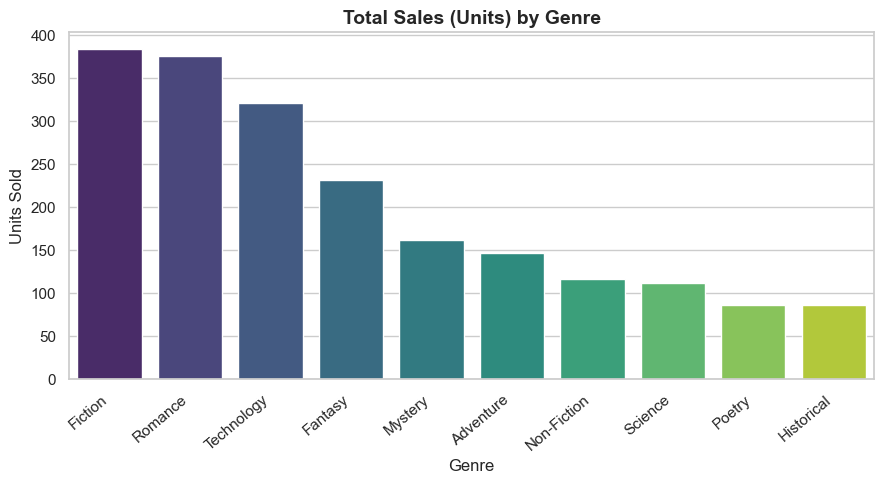

Saved: chart_sales_by_genre.png


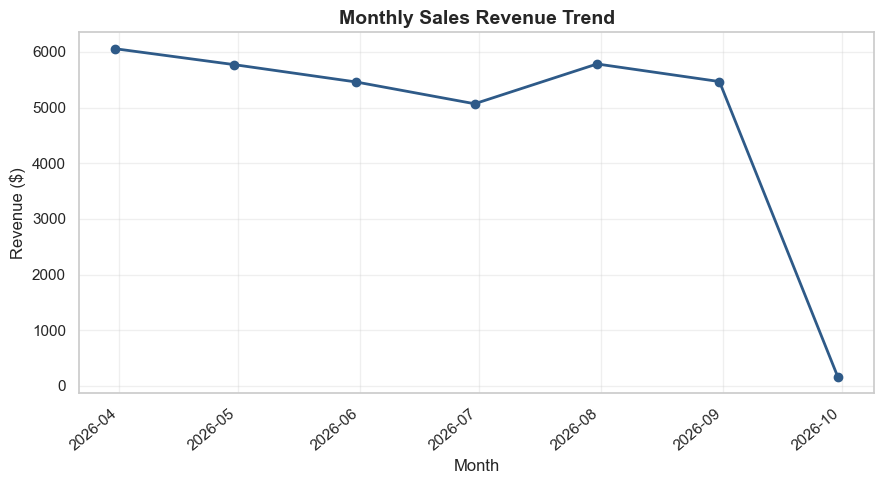

Saved: chart_monthly_trend.png


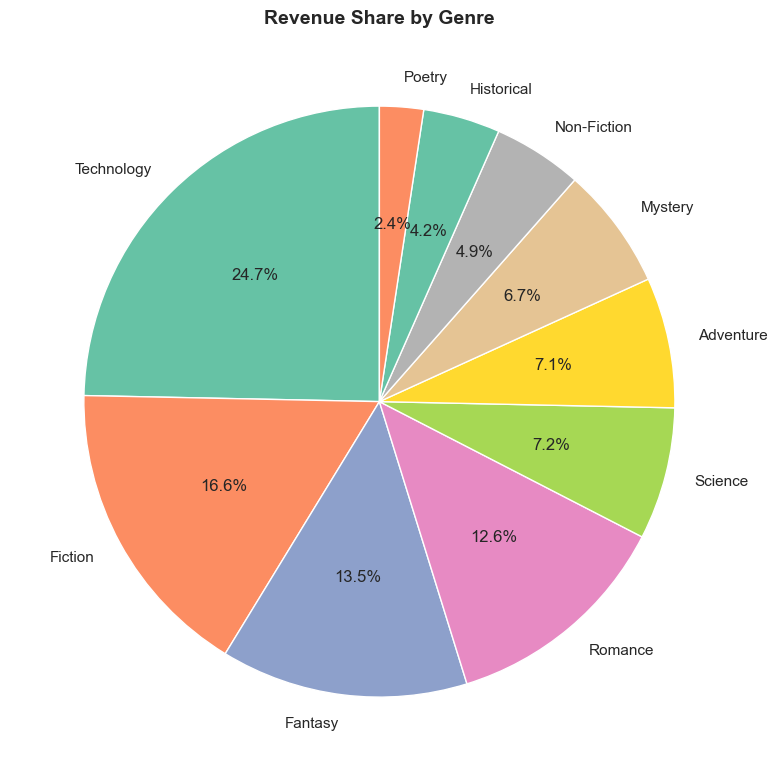

Saved: chart_revenue_pie.png


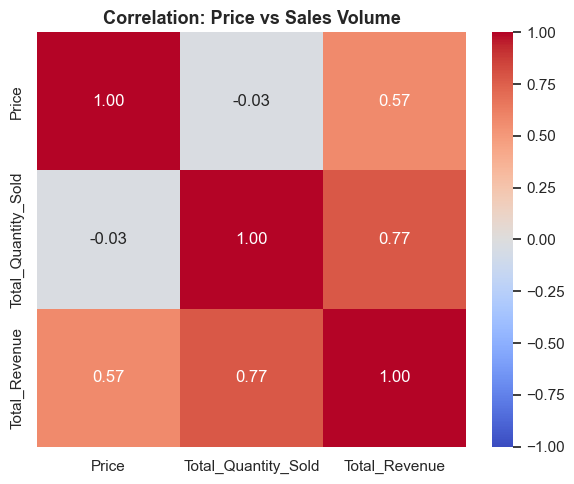

Saved: chart_price_sales_heatmap.png

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  6



Top 5 Best-Selling Books:
                           Total_Quantity  Total_Revenue
Title                                                   
Copper Wire Kingdom                   160        3198.40
Under a Borrowed Moon                 149        1637.51
Static Hearts                         122        1372.50
The Silent Orchard                    109        1633.91
Ghosts of the Data Center             106        2729.50

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  7


Inventory and sales data saved.

----- Bookstore Inventory & Analytics System -----
1. Add a new book
2. Update inventory quantity
3. Record a sale
4. Generate summary report
5. Generate all visualizations (charts saved as PNG)
6. Show best-selling books
7. Save changes to CSV
8. Exit


Select an option (1-8):  8
Save changes before exiting? (y/n):  y


Data saved.
Goodbye!


In [1]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


class Bookstore:
    """
    Core class representing the bookstore. Manages inventory and sales
    data, performs analytics with NumPy/Pandas, and produces
    visualizations with Matplotlib/Seaborn.
    """

    INVENTORY_COLUMNS = ["Title", "Author", "Genre", "Price", "Quantity"]
    SALES_COLUMNS = ["Date", "Title", "Quantity Sold", "Total Revenue"]

    def __init__(self, inventory_path="inventory.csv", sales_path="sales.csv"):
        self.inventory_path = inventory_path
        self.sales_path = sales_path
        self.inventory = self._load_inventory()
        self.sales = self._load_sales()

    # ------------------------------------------------------------------
    # Data loading & cleaning (Pandas)
    # ------------------------------------------------------------------
    def _load_inventory(self):
        """Load inventory.csv into a DataFrame, creating an empty one if missing."""
        if os.path.exists(self.inventory_path):
            df = pd.read_csv(self.inventory_path)
            # Clean: drop rows missing a Title, fill missing numeric values safely
            df = df.dropna(subset=["Title"])
            df["Price"] = pd.to_numeric(df["Price"], errors="coerce").fillna(0.0)
            df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").fillna(0).astype(int)
            return df.reset_index(drop=True)
        return pd.DataFrame(columns=self.INVENTORY_COLUMNS)

    def _load_sales(self):
        """Load sales.csv into a DataFrame, creating an empty one if missing."""
        if os.path.exists(self.sales_path):
            df = pd.read_csv(self.sales_path)
            df = df.dropna(subset=["Title"])
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            df["Quantity Sold"] = pd.to_numeric(df["Quantity Sold"], errors="coerce").fillna(0).astype(int)
            df["Total Revenue"] = pd.to_numeric(df["Total Revenue"], errors="coerce").fillna(0.0)
            df = df.dropna(subset=["Date"])
            return df.reset_index(drop=True)
        return pd.DataFrame(columns=self.SALES_COLUMNS)

    def save(self):
        """Persist current inventory and sales DataFrames back to CSV."""
        self.inventory.to_csv(self.inventory_path, index=False)
        self.sales.to_csv(self.sales_path, index=False)

    # ------------------------------------------------------------------
    # 1. Inventory Management (Control Structures & Arrays)
    # ------------------------------------------------------------------
    def add_book(self, title, author, genre, price, quantity):
        """Add a new book to the inventory, validating inputs first."""
        title, author, genre = str(title).strip(), str(author).strip(), str(genre).strip()

        # --- Control-structure based validation ---
        if not title or not author or not genre:
            print("Error: Title, author, and genre cannot be empty.")
            return False
        try:
            price = float(price)
            quantity = int(quantity)
        except (ValueError, TypeError):
            print("Error: Price and quantity must be numeric.")
            return False
        if price <= 0 or quantity < 0:
            print("Error: Price must be positive and quantity cannot be negative.")
            return False

        # If the book already exists, top up its quantity instead of duplicating
        existing_idx = self.inventory.index[self.inventory["Title"].str.lower() == title.lower()]
        if len(existing_idx) > 0:
            i = existing_idx[0]
            self.inventory.loc[i, "Quantity"] += quantity
            print(f"'{title}' already existed — quantity increased by {quantity}.")
        else:
            new_row = pd.DataFrame([[title, author, genre, price, quantity]], columns=self.INVENTORY_COLUMNS)
            if self.inventory.empty:
                self.inventory = new_row
            else:
                self.inventory = pd.concat([self.inventory, new_row], ignore_index=True)
            print(f"Added new book: '{title}' by {author}.")
        return True

    def update_inventory(self, title, quantity):
        """Update the stock quantity of an existing book (delta can be +/-)."""
        try:
            quantity = int(quantity)
        except (ValueError, TypeError):
            print("Error: Quantity must be an integer.")
            return False

        idx = self.inventory.index[self.inventory["Title"].str.lower() == str(title).lower()]
        if len(idx) == 0:
            print(f"Error: '{title}' not found in inventory.")
            return False

        i = idx[0]
        new_qty = self.inventory.loc[i, "Quantity"] + quantity
        if new_qty < 0:
            print("Error: Update would result in negative stock. Operation cancelled.")
            return False

        self.inventory.loc[i, "Quantity"] = new_qty
        print(f"Updated '{title}' stock to {new_qty} units.")
        return True

    def record_sale(self, title, quantity, date=None):
        """Record the sale of a book: deducts stock and appends a sales entry."""
        try:
            quantity = int(quantity)
        except (ValueError, TypeError):
            print("Error: Quantity sold must be an integer.")
            return False
        if quantity <= 0:
            print("Error: Quantity sold must be positive.")
            return False

        idx = self.inventory.index[self.inventory["Title"].str.lower() == str(title).lower()]
        if len(idx) == 0:
            print(f"Error: '{title}' not found in inventory.")
            return False

        i = idx[0]
        available = self.inventory.loc[i, "Quantity"]
        if quantity > available:
            print(f"Error: Only {available} units of '{title}' in stock.")
            return False

        price = float(self.inventory.loc[i, "Price"])
        total_revenue = round(price * quantity, 2)
        sale_date = pd.Timestamp(date) if date else pd.Timestamp(datetime.now().date())

        # Deduct stock
        self.inventory.loc[i, "Quantity"] = available - quantity

        # Append sale record (keep Date column as proper Timestamps)
        new_sale = pd.DataFrame(
            [[sale_date, self.inventory.loc[i, "Title"], quantity, total_revenue]],
            columns=self.SALES_COLUMNS,
        )
        if self.sales.empty:
            self.sales = new_sale
        else:
            self.sales = pd.concat([self.sales, new_sale], ignore_index=True)
        self.sales["Date"] = pd.to_datetime(self.sales["Date"], errors="coerce")
        print(f"Recorded sale: {quantity} x '{title}' = ${total_revenue}")
        return True

    # ------------------------------------------------------------------
    # 2. Sales Analysis & Computations (NumPy & Pandas)
    # ------------------------------------------------------------------
    def total_revenue(self):
        """Total revenue across all recorded sales (NumPy sum)."""
        return float(np.sum(self.sales["Total Revenue"].to_numpy())) if not self.sales.empty else 0.0

    def average_price(self):
        """Average book price across the inventory (NumPy mean)."""
        return float(np.mean(self.inventory["Price"].to_numpy())) if not self.inventory.empty else 0.0

    def monthly_sales_growth(self):
        """
        Month-over-month revenue growth rate (%) using NumPy.
        Returns a Series indexed by month.
        """
        if self.sales.empty:
            return pd.Series(dtype=float)
        monthly = self.sales.set_index("Date").resample("ME")["Total Revenue"].sum()
        values = monthly.to_numpy(dtype=float)
        growth = np.zeros_like(values)
        for i in range(1, len(values)):
            growth[i] = ((values[i] - values[i - 1]) / values[i - 1] * 100) if values[i - 1] != 0 else 0.0
        return pd.Series(growth, index=monthly.index, name="Growth %")

    def best_selling_books(self, top_n=5):
        """Top N best-selling books by total quantity sold (Pandas groupby)."""
        if self.sales.empty:
            return pd.DataFrame()
        summary = (
            self.sales.groupby("Title")
            .agg(Total_Quantity=("Quantity Sold", "sum"), Total_Revenue=("Total Revenue", "sum"))
            .sort_values("Total_Quantity", ascending=False)
        )
        return summary.head(top_n)

    def revenue_by_genre(self):
        """Revenue distribution grouped by genre (merge sales with inventory)."""
        if self.sales.empty or self.inventory.empty:
            return pd.Series(dtype=float)
        merged = self.sales.merge(
            self.inventory[["Title", "Genre"]].drop_duplicates("Title"), on="Title", how="left"
        )
        return merged.groupby("Genre")["Total Revenue"].sum().sort_values(ascending=False)

    def sales_by_author(self):
        """Total quantity sold grouped by author."""
        if self.sales.empty or self.inventory.empty:
            return pd.Series(dtype=float)
        merged = self.sales.merge(
            self.inventory[["Title", "Author"]].drop_duplicates("Title"), on="Title", how="left"
        )
        return merged.groupby("Author")["Quantity Sold"].sum().sort_values(ascending=False)

    def generate_report(self):
        """Print a summary of inventory and sales metrics."""
        print("\n" + "=" * 55)
        print("BOOKSTORE SUMMARY REPORT")
        print("=" * 55)
        print(f"Books in catalog        : {len(self.inventory)}")
        print(f"Total units in stock    : {int(self.inventory['Quantity'].sum()) if not self.inventory.empty else 0}")
        print(f"Average book price      : ${self.average_price():.2f}")
        print(f"Total sales transactions: {len(self.sales)}")
        print(f"Total revenue to date   : ${self.total_revenue():,.2f}")

        best = self.best_selling_books(3)
        if not best.empty:
            print("\nTop 3 best-selling books:")
            for title, row in best.iterrows():
                print(f"  - {title}: {int(row['Total_Quantity'])} units, ${row['Total_Revenue']:.2f} revenue")

        low_stock = self.inventory[self.inventory["Quantity"] < 10]
        if not low_stock.empty:
            print("\nLow stock alert (< 10 units):")
            for _, row in low_stock.iterrows():
                print(f"  - {row['Title']}: {row['Quantity']} units left")
        print("=" * 55 + "\n")

    # ------------------------------------------------------------------
    # 3. Data Visualization (Matplotlib & Seaborn)
    # ------------------------------------------------------------------
    def visualize_sales_by_genre(self, save_path="chart_sales_by_genre.png"):
        """Bar chart: total sales (quantity) by genre."""
        if self.sales.empty or self.inventory.empty:
            print("No sales data available to visualize.")
            return
        merged = self.sales.merge(
            self.inventory[["Title", "Genre"]].drop_duplicates("Title"), on="Title", how="left"
        )
        genre_sales = merged.groupby("Genre")["Quantity Sold"].sum().sort_values(ascending=False)

        plt.figure(figsize=(9, 5))
        sns.barplot(x=genre_sales.index, y=genre_sales.values, hue=genre_sales.index,
                    palette="viridis", legend=False)
        plt.title("Total Sales (Units) by Genre", fontsize=14, fontweight="bold")
        plt.xlabel("Genre")
        plt.ylabel("Units Sold")
        plt.xticks(rotation=40, ha="right")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
        plt.close()
        print(f"Saved: {save_path}")

    def visualize_monthly_trend(self, save_path="chart_monthly_trend.png"):
        """Line graph: monthly sales revenue trend."""
        if self.sales.empty:
            print("No sales data available to visualize.")
            return
        monthly = self.sales.set_index("Date").resample("ME")["Total Revenue"].sum()

        plt.figure(figsize=(9, 5))
        plt.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#2E5A88")
        plt.title("Monthly Sales Revenue Trend", fontsize=14, fontweight="bold")
        plt.xlabel("Month")
        plt.ylabel("Revenue ($)")
        plt.xticks(rotation=40, ha="right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
        plt.close()
        print(f"Saved: {save_path}")

    def visualize_revenue_share_by_genre(self, save_path="chart_revenue_pie.png"):
        """Pie chart: revenue share by book genre."""
        genre_revenue = self.revenue_by_genre()
        if genre_revenue.empty:
            print("No sales data available to visualize.")
            return

        plt.figure(figsize=(8, 8))
        colors = sns.color_palette("Set2", len(genre_revenue))
        plt.pie(
            genre_revenue.values,
            labels=genre_revenue.index,
            autopct="%1.1f%%",
            startangle=90,
            colors=colors,
        )
        plt.title("Revenue Share by Genre", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
        plt.close()
        print(f"Saved: {save_path}")

    def visualize_price_sales_correlation(self, save_path="chart_price_sales_heatmap.png"):
        """Heatmap: correlation between book price and sales volume."""
        if self.sales.empty or self.inventory.empty:
            print("No sales data available to visualize.")
            return
        merged = self.sales.merge(
            self.inventory[["Title", "Price"]].drop_duplicates("Title"), on="Title", how="left"
        )
        per_title = merged.groupby("Title").agg(
            Price=("Price", "first"),
            Total_Quantity_Sold=("Quantity Sold", "sum"),
            Total_Revenue=("Total Revenue", "sum"),
        )
        corr = per_title[["Price", "Total_Quantity_Sold", "Total_Revenue"]].corr()

        plt.figure(figsize=(6, 5))
        sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
        plt.title("Correlation: Price vs Sales Volume", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
        plt.close()
        print(f"Saved: {save_path}")

    def generate_all_visualizations(self):
        """Convenience method to produce all four required charts."""
        self.visualize_sales_by_genre()
        self.visualize_monthly_trend()
        self.visualize_revenue_share_by_genre()
        self.visualize_price_sales_correlation()


# ==========================================================================
# Interactive CLI (Control Structures: loops + conditionals for user menu)
# ==========================================================================
def print_menu():
    print("\n----- Bookstore Inventory & Analytics System -----")
    print("1. Add a new book")
    print("2. Update inventory quantity")
    print("3. Record a sale")
    print("4. Generate summary report")
    print("5. Generate all visualizations (charts saved as PNG)")
    print("6. Show best-selling books")
    print("7. Save changes to CSV")
    print("8. Exit")


def run_cli():
    store = Bookstore()
    print("Bookstore system loaded:")
    print(f"  {len(store.inventory)} books in inventory, {len(store.sales)} sales records.")

    while True:  # main event loop
        print_menu()
        choice = input("Select an option (1-8): ").strip()

        if choice == "1":
            title = input("Title: ").strip()
            author = input("Author: ").strip()
            genre = input("Genre: ").strip()
            price = input("Price: ").strip()
            quantity = input("Quantity: ").strip()
            store.add_book(title, author, genre, price, quantity)

        elif choice == "2":
            title = input("Title to update: ").strip()
            quantity = input("Quantity change (e.g. 10 or -5): ").strip()
            store.update_inventory(title, quantity)

        elif choice == "3":
            title = input("Title sold: ").strip()
            quantity = input("Quantity sold: ").strip()
            store.record_sale(title, quantity)

        elif choice == "4":
            store.generate_report()

        elif choice == "5":
            store.generate_all_visualizations()

        elif choice == "6":
            best = store.best_selling_books(5)
            if best.empty:
                print("No sales data yet.")
            else:
                print("\nTop 5 Best-Selling Books:")
                print(best.to_string())

        elif choice == "7":
            store.save()
            print("Inventory and sales data saved.")

        elif choice == "8":
            save_choice = input("Save changes before exiting? (y/n): ").strip().lower()
            if save_choice == "y":
                store.save()
                print("Data saved.")
            print("Goodbye!")
            return  

        else:
            print("Invalid option. Please choose a number from 1 to 8.")


if __name__ == "__main__":
    run_cli()